# Import Essential Libraries

In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from sklearn.model_selection  import train_test_split,GridSearchCV
from sklearn.pipeline  import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error


# import models
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore',category=FutureWarning)


# Load the Data

In [10]:
data_path = '/home/talha/Projects/student-score-project/datasets/student_data.csv'
student_data =  pd.read_csv(data_path)

In [11]:
# Head of dataset
print('='*12,'Head of Dataset','='*12)
print(student_data.head())
# Tail of data set
print('='*12,'Tail of Dataset','='*12)
print(student_data.tail())
# Info of Dataset
print('='*12,'Info of Dataset','='*12)
print(student_data.info())
# Missing values
print('='*12,'Missing values in Dataset','='*12)
print(student_data.isnull().sum())

============ Head of Dataset ============
   student_id  age  gender school_type parent_education  study_hours  \
0           1   14    male      public    post graduate          3.1   
1           2   18  female      public         graduate          3.7   
2           3   17  female     private    post graduate          7.9   
3           4   16   other      public      high school          1.1   
4           5   16  female      public      high school          1.3   

   attendance_percentage internet_access travel_time extra_activities  \
0                   84.3             yes     <15 min              yes   
1                   87.8             yes     >60 min               no   
2                   65.5              no     <15 min               no   
3                   58.1              no   15-30 min               no   
4                   61.0             yes   30-60 min              yes   

  study_method  math_score  science_score  english_score  overall_score  \
0        no

# Exploratory Data Analysis (EDA)

Distribution of Final Grades

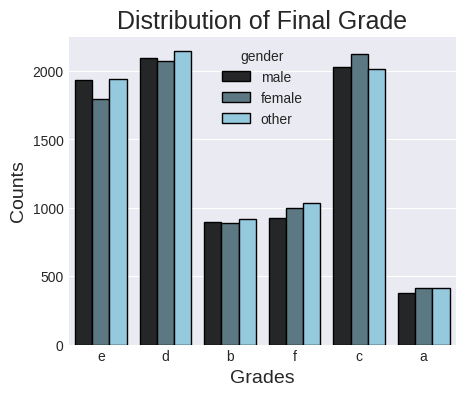

In [12]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
#  Distrubutive of final grade
plt.figure(figsize = (5,4))

sns.countplot(data= student_data,x= "final_grade", hue="gender", color='skyblue', edgecolor='black')
plt.title('Distribution of Final Grade',fontsize=18)
plt.xlabel('Grades',fontsize=14)
plt.ylabel('Counts',fontsize=14)
# plt.xticks(rotation=1)
plt.show()



 Correlation Graph

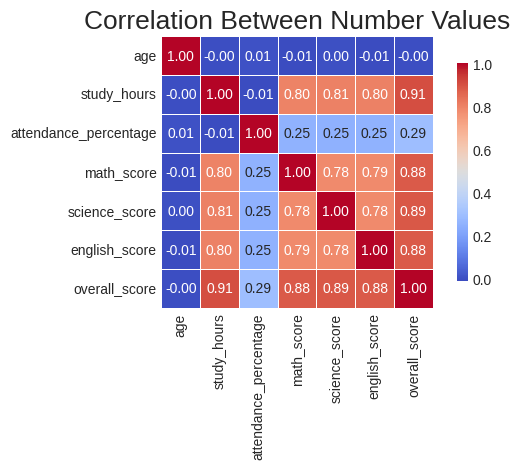

In [13]:
numerical_col = student_data.select_dtypes(exclude='object').drop('student_id',axis=1)
corr = numerical_col.corr()
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            square=True,
            linewidth=0.5,
            cbar_kws={'shrink':0.8})
plt.title('Correlation Between Number Values',fontsize=19 )
plt.tight_layout()
plt.show()

Subjects Wise Comparison of Scores

Columns Effects on Target Variable(overall_score)

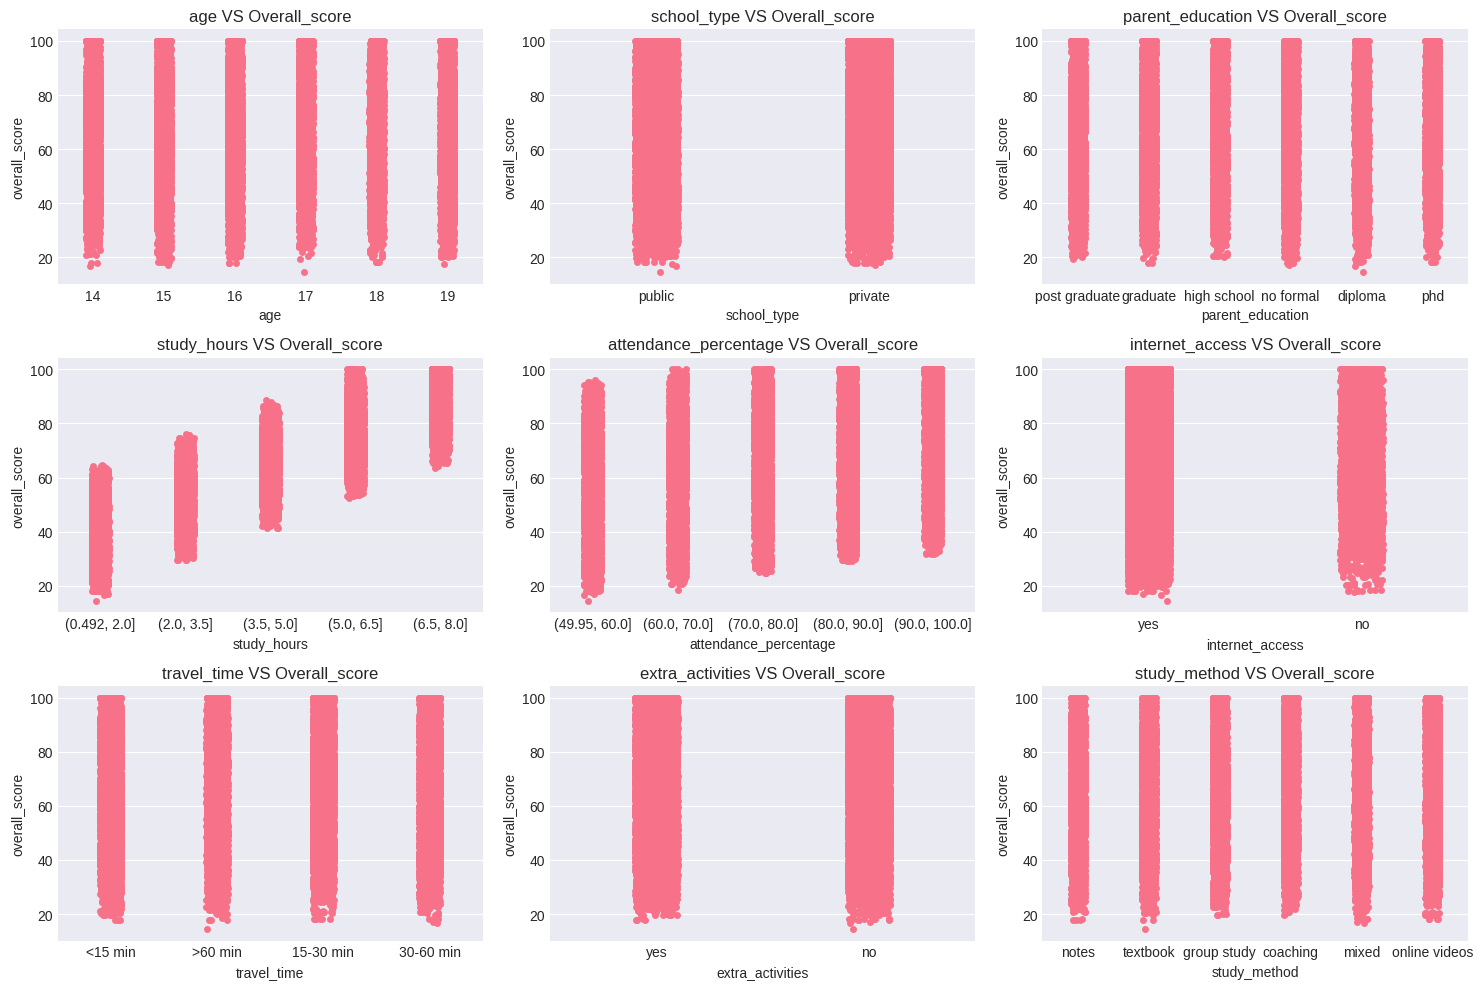

In [ ]:
# Selection of  Columns that has effects target
e_columns = ['age','school_type', 'parent_education','study_hours','attendance_percentage','internet_access',
       'travel_time','extra_activities','study_method']
# using for_loop for comparing
fig ,axes = plt.subplots(3,3,figsize=(15,10))
axes= axes.flatten()

for i in e_columns:
    if i in ['study_hours','attendance_percentage']:
        bins = pd.cut(student_data[i],bins=5)
        sns.stripplot(x=bins,y=student_data['overall_score'],hue=student_data['gender'],ax=axes[e_columns.index(i)])
        axes[e_columns.index(i)].set_title(f'{i} VS Overall_score')

    else:
        sns.stripplot(x=student_data[i],y=student_data['overall_score'],hue= student_data['gender'], ax=axes[e_columns.index(i)])
        axes[e_columns.index(i)].set_title(f'{i} VS Overall_score')
plt.tight_layout()
plt.show()
#plt.tight_layout()
#plt.show()

# Feature Engineering Strategy

In [ ]:
# Average marks column 
student_data['avg_subject_score'] = (student_data['science_score']+student_data['english_score']+student_data['math_score'])/3
# Score Variance
student_data['score_variance'] = student_data[['math_score','science_score','english_score']].var(axis=1)
student_data['study_efficiency'] = student_data['overall_score']/student_data['study_hours']


# Transformation

In [ ]:
print(student_data.columns)
student_data.info()

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'math_score',
       'science_score', 'english_score', 'overall_score', 'final_grade',
       'avg_subject_score', 'score_variance', 'study_efficiency'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object

In [ ]:
nominal_columns = [
    'gender',              # male/female/other
    'school_type',         # public/private
    'internet_access',     # yes/no
    'extra_activities'     # yes/no
]
ordinal_columns = [
    'parent_education',    # no formal < high school < diploma < graduate < post graduate < phd
    'travel_time',         # <15min < 15-30min < 30-60min < >60min
    'study_method'         # notes < textbook < mixed < coaching < group study (based on effectiveness)
]
numerical_columns = ['age','study_hours','attendance_percentage','study_efficiency']  # For classification


In [ ]:
# Give order the cloumns
parent_education_order = ['no formal','high school','diploma','graduate','post graduate','phd']
travel_time_order = ['<15 min','15-30 min','30-60 min','>60 min']
study_method_order = ['notes','textbook','mixed','coaching','group study','online videos']

In [ ]:
column_transform = ColumnTransformer(
    transformers=[
        #Nominal Columns
        ('nominal',
        Pipeline([
            ('encoder',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'))
            ]),
            nominal_columns),
            
        #Ordinal Cloumns
        ('ordinal',Pipeline([
            ('encoder',OrdinalEncoder(categories=[
        parent_education_order,
        travel_time_order,
        study_method_order
           ]))
        ]),
        ordinal_columns),
        
        #Numerical columns
        ('numerical',Pipeline([
            ('scaler',StandardScaler())
        ]),
        numerical_columns)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

In [ ]:
# Features (X) and Target (y)
X = student_data.drop(['student_id','math_score','science_score','english_score','overall_score','final_grade'],axis=1)
y = student_data['overall_score']

# transform the data
X_processed = column_transform.fit_transform(X)

# Names of features
try:
    features_name = column_transform.get_feature_names_out()
    print(f'Features:{features_name[:]}')
except:
    print('features names are available')

Features:['gender_male' 'gender_other' 'school_type_public' 'internet_access_yes'
 'extra_activities_yes' 'parent_education' 'travel_time' 'study_method'
 'age' 'study_hours' 'attendance_percentage' 'study_efficiency']


# Split data into test and train

In [ ]:
# Split 80% for train and 20% for test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("train data shape : ",X_train.shape)
print("\n test data shape : ",X_test.shape)

train data shape :  (20000, 13)

 test data shape :  (5000, 13)


# Pipelines for Model

In [ ]:
# Linear Regression Pipeline
lr_model = Pipeline([
    ['preprocessor',column_transform],
    ['regressor',LinearRegression()]
])

# Ridge Pipeline
rig_model = Pipeline([
    ['reprocessor',column_transform],
    ['regressor',Ridge(alpha=0.1)]
])

# Lasso Pipeline
las_model = Pipeline([
    ['preprocessor',column_transform],
    ['regressor',Lasso(alpha=0.1)]
])

# Random Forest Pipeline
rf_model = Pipeline([
    ('preprocessor',column_transform),
    ('regressor',RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ))
])

# XGBoost Pipeline
xgb_model = Pipeline([
    ('preprocessor',column_transform),
    ('regressor',XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=10,
        random_state=42
    ))
])

# Gredient Boosting Pipeline
gb_model = Pipeline([
    ('preprocessor',column_transform),
    ('regressor',GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
    ))
])

# Train all the Models

In [ ]:
# Firstly train the RandomForestModel
rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)
r2_rf = r2_score(rf_pred,y_test)
rmse_rf = root_mean_squared_error(rf_pred,y_test)

# Secondly train the XGBoost Model
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
r2_xgb = r2_score(xgb_pred,y_test)
rmse_xgb = root_mean_squared_error(xgb_pred,y_test)

# Thirdly train the GradientBoosting Model
gb_model.fit(X_train,y_train)
gb_pred = gb_model.predict(X_test)
r2_gb = r2_score(gb_pred,y_test)
rmse_gb = root_mean_squared_error(gb_pred,y_test)

# Choose the best model

In [ ]:
# performance of all the model 
print("="*23)
print("Performance of Models")
print("="*23)
print(f"r2_score of Random Forest : {r2_rf:.3f} and rmse : {rmse_rf:.3f}")
print(f"r2_score of XG Boost      : {r2_xgb:.3f} and rmse : {rmse_xgb:.3f}")
print(f"r2_score of Gradient Boos : {r2_rf:.3f} and rmse : {rmse_gb:.3f}")

# best score
score = {
    "Random Forest"      : r2_rf,
    "XG Boost"           : r2_xgb,
    "Gadien Boosting"    : r2_gb
} 
best = max(score, key= score.get)
print(f'The best model : {best}  and the score is {score[best]:.3f}')

Performance of Models
r2_score of Random Forest : 0.999 and rmse : 0.658
r2_score of XG Boost      : 1.000 and rmse : 0.340
r2_score of Gradient Boos : 0.999 and rmse : 2.045
The best model : XG Boost  and the score is 1.000


#   Testing real values

In [ ]:
print(X_train.select_dtypes(exclude='object').columns)
print('s' )
print(X_train.columns)

Index(['age', 'study_hours', 'attendance_percentage', 'avg_subject_score',
       'score_variance', 'study_efficiency'],
      dtype='object')
s
Index(['age', 'gender', 'school_type', 'parent_education', 'study_hours',
       'attendance_percentage', 'internet_access', 'travel_time',
       'extra_activities', 'study_method', 'avg_subject_score',
       'score_variance', 'study_efficiency'],
      dtype='object')


In [ ]:
# getting values 
features_keys = dict(X_train).keys()
features_keys
for i in features_keys:
    print(f'values of {i}',X_train[i].unique())
    

values of age [14 19 15 18 16 17]
values of gender ['male' 'female' 'other']
values of school_type ['public' 'private']
values of parent_education ['post graduate' 'high school' 'phd' 'graduate' 'diploma' 'no formal']
values of study_hours [6.7 1.1 4.8 4.7 5.8 5.5 5.2 4.1 2.9 2.  4.6 6.1 4.2 4.4 2.3 5.  2.7 5.6
 3.3 4.9 7.2 0.7 3.  1.6 6.8 7.5 0.6 5.7 3.6 6.6 8.  2.5 6.5 1.7 7.8 6.
 3.2 7.  6.9 2.6 1.2 7.7 3.8 5.9 4.3 3.7 4.  7.6 6.3 0.8 2.4 4.5 6.4 3.5
 7.9 5.3 0.9 1.5 7.1 1.9 0.5 5.4 6.2 7.4 2.2 3.4 7.3 1.  1.8 3.1 2.1 1.3
 5.1 3.9 1.4 2.8]
values of attendance_percentage [ 59.1  56.   89.8  92.2  52.6  80.7  60.6  65.1  73.8  75.7  58.3  81.
  91.5  59.9  90.1  85.1  54.7  90.2  88.3  92.3  70.4  74.   75.5  95.8
  78.7  60.8  99.5  96.   93.8  91.8  65.3  63.2  51.1  94.3  56.4  61.1
  99.8  70.9  57.2  96.2  62.5  67.   75.2  66.   58.2  98.1  53.8  80.
  91.3  67.7  85.6  80.4  52.1  77.2  68.4  51.2  71.4  64.4  81.6  65.5
  56.5  56.8  75.   60.   83.5  69.1  86.6  91.2  85.9  

In [ ]:
# numerical features
num_features_keys = ['age', 'study_hours', 'attendance_percentage',
       'score_variance', 'study_efficiency']

# we use loop for this
test_values = {}
for i in num_features_keys:
    print(f'Enter the {i} :')
    value = eval(input())
    test_values[i] = value
    print(test_values)

Enter the age :


{'age': 15}
Enter the study_hours :
{'age': 15, 'study_hours': 5}
Enter the attendance_percentage :
{'age': 15, 'study_hours': 5, 'attendance_percentage': 70}
Enter the avg_subject_score :


SyntaxError: invalid syntax (<string>, line 0)